# Quench $G(t,0)$ comparison

Compares the quench-time correlator $G(t,0)$ -- the two-time Green's function $G^>(t_1,t_2)$ sliced at the quench instant $t_2=0$ -- between two `kbe-one` runs at the same physical parameters (one from the `syk_sims` production sweep, one from a local `run_local_eq.sh`/`run_local_kbe.sh` run), as a check that they agree.

For $t\ge0$ this is read directly off the saved post-quench block `Ggt_post`. For $t<0$ the pre-quench $(t_1,t_2\le0)$ block isn't stored -- it's exactly the known equilibrium solution, translation-invariant as $G(t_1,t_2)=G_{\rm eq}(t_1-t_2)$ -- so it's reconstructed from the separately-saved one-time equilibrium trace `Ggt_eq_t`/`t_eq`. The quench sits at $t=0$.

In [7]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8.2, 5.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## Files to compare

In [8]:
runs = {
    "syk_sims (production)": Path(
        "/Users/meabh/Desktop/CC Quench States/SYK Quenches/syk_sims/kbe_runs/"
        "syk_kbe_J2_0_to_0_J4_1_to_1_beta_12_dt_0p1_tpre_24_tpost_12_ncorr_8_ctol_1em05_5b17997f.npz"
    ),
    "local_runs (local)": Path(
        "/Users/meabh/Desktop/CC Quench States/SYK Quenches/local_runs/kbe_runs/"
        "syk_kbe_J2_0_to_0_J4_1_to_1_beta_12_dt_0p1_tpre_24_tpost_12_ncorr_8_ctol_1em05_3a931a77.npz"
    ),
}

colors = {"syk_sims (production)": "tab:blue", "local_runs (local)": "tab:orange"}
linestyles = {"syk_sims (production)": "-", "local_runs (local)": "--"}

## Load $G(t,0)$

In [9]:
def load_quench_G_t0(filename):
    with np.load(filename, allow_pickle=True) as data:
        meta = json.loads(str(data["metadata_json"]))
        t_row_post = np.asarray(data["t_row_post"], dtype=float)
        t_col_all = np.asarray(data["t_col_all"], dtype=float)
        Ggt_post = np.asarray(data["Ggt_post"], dtype=complex)
        n0 = int(np.asarray(data["n0"]).item())
        t_eq = np.asarray(data["t_eq"], dtype=float)
        Ggt_eq_t = np.asarray(data["Ggt_eq_t"], dtype=complex)

    # t >= 0 (post-quench): read directly off the saved two-time block.
    G_post = Ggt_post[:, n0]

    # t < 0 (pre-quench): reconstruct from the one-time equilibrium trace via
    # G(t1, 0) = G_eq(t1 - 0) = G_eq(t1), t1<0.
    t_pre = t_col_all[t_col_all < 0]
    G_pre = (
        np.interp(t_pre, t_eq, Ggt_eq_t.real)
        + 1j * np.interp(t_pre, t_eq, Ggt_eq_t.imag)
    )

    t_full = np.concatenate([t_pre, t_row_post])
    G_full = np.concatenate([G_pre, G_post])
    order = np.argsort(t_full)
    return t_full[order], G_full[order], meta


loaded = {label: load_quench_G_t0(path) for label, path in runs.items()}

for label, (t, G, meta) in loaded.items():
    print(f"{label}: {runs[label].name}")
    print(
        f"  beta={meta['beta']:g}  J4_i->J4_f={meta['J4_i']:g}->{meta['J4_f']:g}  "
        f"dt={meta['dt']:g}  t_pre={meta['t_pre']:g}  t_post={meta['t_post']:g}"
    )
    print(
        f"  eq kernel: lambda={meta['eq_kernel_lambda']:g} "
        f"c={meta['eq_kernel_c']:g} cutoff={meta['eq_kernel_cutoff']:g}"
    )

syk_sims (production): syk_kbe_J2_0_to_0_J4_1_to_1_beta_12_dt_0p1_tpre_24_tpost_12_ncorr_8_ctol_1em05_5b17997f.npz
  beta=12  J4_i->J4_f=1->1  dt=0.1  t_pre=24  t_post=12
  eq kernel: lambda=0.005 c=-0.043936 cutoff=0.65
local_runs (local): syk_kbe_J2_0_to_0_J4_1_to_1_beta_12_dt_0p1_tpre_24_tpost_12_ncorr_8_ctol_1em05_3a931a77.npz
  beta=12  J4_i->J4_f=1->1  dt=0.1  t_pre=24  t_post=12
  eq kernel: lambda=0.005 c=-0.043936 cutoff=0.65


## $|G(t,0)|$

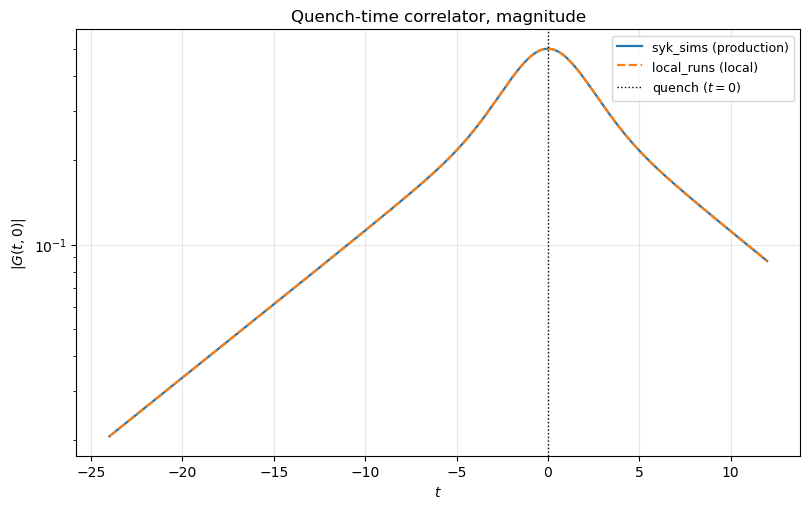

In [10]:
fig, ax = plt.subplots()

for label, (t, G, meta) in loaded.items():
    ax.plot(t, np.abs(G), lw=1.6, color=colors[label], ls=linestyles[label], label=label)

ax.axvline(0.0, color="black", lw=1, ls=":", label="quench ($t=0$)")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$|G(t,0)|$")
ax.set_yscale("log")
ax.set_title("Quench-time correlator, magnitude")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## $\operatorname{Re}G(t,0)$ and $\operatorname{Im}G(t,0)$

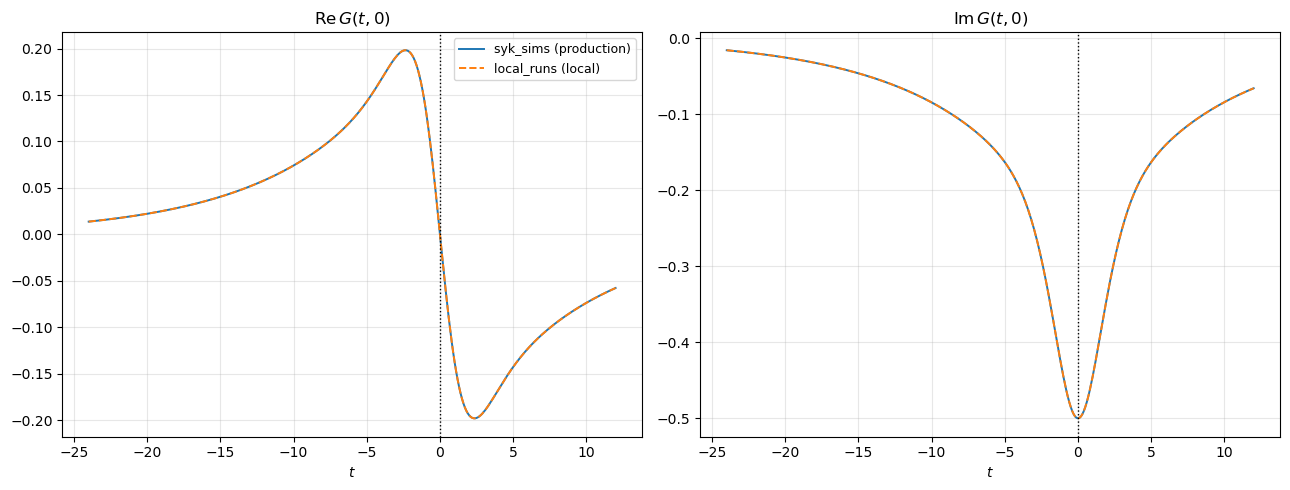

In [11]:
fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(13, 5))

for label, (t, G, meta) in loaded.items():
    ax_re.plot(t, G.real, lw=1.4, color=colors[label], ls=linestyles[label], label=label)
    ax_im.plot(t, G.imag, lw=1.4, color=colors[label], ls=linestyles[label], label=label)

for ax, title in [(ax_re, r"$\operatorname{Re}G(t,0)$"), (ax_im, r"$\operatorname{Im}G(t,0)$")]:
    ax.axvline(0.0, color="black", lw=1, ls=":")
    ax.set_xlabel(r"$t$")
    ax.set_title(title)

ax_re.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Agreement between the two runs

Interpolates one run's $G(t,0)$ onto the other's time grid (they share the same `dt`, but grids need not line up to floating-point precision) and plots the pointwise difference.

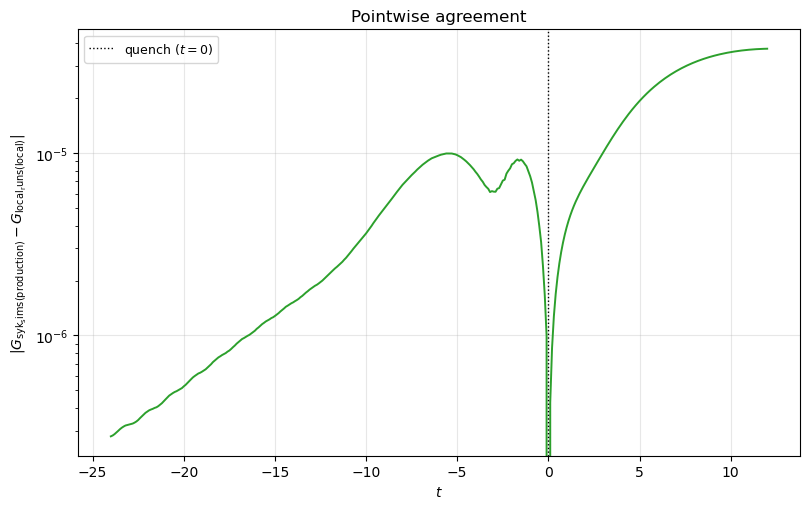

max |difference| = 3.733e-05
max |G| (run A)   = 5.000e-01


In [12]:
(label_a, (t_a, G_a, _)), (label_b, (t_b, G_b, _)) = list(loaded.items())

G_b_on_a = (
    np.interp(t_a, t_b, G_b.real) + 1j * np.interp(t_a, t_b, G_b.imag)
)
diff = np.abs(G_a - G_b_on_a)

fig, ax = plt.subplots()
ax.plot(t_a, diff, lw=1.4, color="tab:green")
ax.axvline(0.0, color="black", lw=1, ls=":", label="quench ($t=0$)")
ax.set_xlabel(r"$t$")
ax.set_ylabel(rf"$|G_{{\rm {label_a}}} - G_{{\rm {label_b}}}|$")
ax.set_yscale("log")
ax.set_title("Pointwise agreement")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"max |difference| = {diff.max():.3e}")
print(f"max |G| (run A)   = {np.abs(G_a).max():.3e}")